### PKL structure

In [2]:
import pandas as pd, numpy as np, os, json

#paths
TRAIN_PKL  = "/home/suba/Documents/GitHub/qtaim_embed_private/data_suba/train_qm9_qtaim_1205_labelled_corrected_my43k.pkl"
TEST_PKL   = "/home/suba/Documents/GitHub/qtaim_embed_private/data_suba/test_qm9_qtaim_1205_labelled_corrected_my43k.pkl"
QTAIM_ROOT = "/home/suba/Downloads/qtaim_generator/qtaim_generator/data/qm9/QTAIM/"
OUTPUT_PKL = "/home/suba/Documents/GitHub/qtaim_embed_private/data_suba/qm9_with_corrected_qtaim.pkl"

#load data
train = pd.read_pickle(TRAIN_PKL)
test  = pd.read_pickle(TEST_PKL)
train["split"] = "train"
test["split"]  = "test"
df = pd.concat([train, test], ignore_index=True)
df["gdb_num"] = df["names"].str.extract(r"gdb_(\d+)\.xyz").astype(int)

print(f"Dataset: {len(df)} molecules  ({len(df.columns)} columns)")
print()
print("Key columns for graph construction:")
print(f"  names                          : molecule name, e.g. gdb_21159.xyz")
print(f"  ids                            : qtaim_generator internal job ID")
print(f"  gdb_num                        : QM9 database index (extracted from names)")
print(f"  bonds                          : bond pair list — USED AS GRAPH TOPOLOGY")
print(f"  extra_feat_bond_indices_qtaim  : bond pair index for feature lookup")
print(f"  extra_feat_bond_*              : 19 QTAIM bond features (one value per bond)")
print(f"  extra_feat_atom_*              : 19 QTAIM atom features (one value per atom)")
print(f"  molecule_graph                 : pymatgen MoleculeGraph (ground truth topology)")
print(f"  homo / lumo / gap              : prediction targets")
print()

# show sample row
row = df[df["gdb_num"] == 21159].iloc[0]
print(f"Sample molecule: {row['names']}  ids={row['ids']}  gdb_num={row['gdb_num']}")
print(f"  bonds column    : {row['bonds']}")
print(f"  n_bonds in PKL  : {len(row['bonds'][0]) if isinstance(row['bonds'][0], list) else len(row['bonds'])}")

mg = row["molecule_graph"]
mg_edges = {(min(u,v),max(u,v)) for u,v,_ in mg.graph.edges(data=True)}
print(f"  n_bonds in mg   : {len(mg_edges)}  (ground truth)")


Dataset: 43476 molecules  (64 columns)

Key columns for graph construction:
  names                          : molecule name, e.g. gdb_21159.xyz
  ids                            : qtaim_generator internal job ID
  gdb_num                        : QM9 database index (extracted from names)
  bonds                          : bond pair list — USED AS GRAPH TOPOLOGY
  extra_feat_bond_indices_qtaim  : bond pair index for feature lookup
  extra_feat_bond_*              : 19 QTAIM bond features (one value per bond)
  extra_feat_atom_*              : 19 QTAIM atom features (one value per atom)
  molecule_graph                 : pymatgen MoleculeGraph (ground truth topology)
  homo / lumo / gap              : prediction targets

Sample molecule: gdb_21159.xyz  ids=123092  gdb_num=21159
  bonds column    : [[(4, 12), (5, 14), (4, 5), (5, 5), (5, 6), (3, 5), (6, 7), (3, 7), (1, 3), (1, 11), (0, 1), (0, 10)]]
  n_bonds in PKL  : 12
  n_bonds in mg   : 15  (ground truth)


### Bug: ids vs gdb_num   Folder mismatch while creating pkl

`qtaim_generator` assigned each molecule a sequential internal job ID (`ids`) and wrote
QTAIM output to `QTAIM_ROOT/<ids>/`. When building the PKL, it read bond topology from
`QTAIM_ROOT/<gdb_num>/` — a completely different molecule for every row.

```
gdb_num = QM9 database index  (e.g. 21159)  ← folder used to build PKL bonds
ids     = internal job ID      (e.g. 123092) ← folder where QTAIM output actually lives
```

For molecule `gdb_21159`: `gdb_num=21159 ≠ ids=123092` → bonds came from a different molecule.

In [2]:
# Demonstrate the mismatch for gdb_21159
SAMPLE_GDB = 21159
row = df[df["gdb_num"] == SAMPLE_GDB].iloc[0]
mol_id = int(row["ids"])

print(f"Molecule: {row['names']}")
print(f"  gdb_num = {SAMPLE_GDB}  (QM9 index — what PKL used as folder)")
print(f"  ids     = {mol_id}  (qtaim_generator job ID — correct folder)")
print()

# Check coordinate match: ids folder vs gdb_num folder
mg  = row["molecule_graph"]
mol = mg.molecule

def get_species(site):
    for attr in ("specie","species_string"):
        try:
            v = getattr(site, attr)
            return v.symbol if hasattr(v,"symbol") else str(v).split(":")[0]
        except: pass
    return "?"

for label, folder_id in [(f"gdb_num={SAMPLE_GDB} (WRONG)", SAMPLE_GDB),
                          (f"ids={mol_id} (CORRECT)",      mol_id)]:
    qpath = os.path.join(QTAIM_ROOT, str(folder_id), "qtaim.json")
    if not os.path.exists(qpath):
        print(f"{label}: folder not found"); continue
    with open(qpath) as f: q = json.load(f)
    atom_keys = sorted([k for k in q if "_" not in str(k)], key=lambda x: int(x))
    n_match = 0
    for k in atom_keys:
        idx = int(k)
        if idx >= len(mol.sites): break
        diff = np.max(np.abs(np.array(q[k]["pos_ang"]) - np.array(mol.sites[idx].coords)))
        if diff < 0.05: n_match += 1
    bcp_pairs = {(min(int(k.split("_")[0]),int(k.split("_")[1])),
                   max(int(k.split("_")[0]),int(k.split("_")[1])))
                  for k in q if "_" in str(k)}
    mg_edges = {(min(u,v),max(u,v)) for u,v,_ in mg.graph.edges(data=True)}
    print(f"  {label}:")
    print(f"    atom coord matches : {n_match}/{len(atom_keys)}")
    print(f"    bcp == mg_edges?   : {bcp_pairs == mg_edges}")
    print()


Molecule: gdb_21159.xyz
  gdb_num = 21159  (QM9 index — what PKL used as folder)
  ids     = 123092  (qtaim_generator job ID — correct folder)

  gdb_num=21159 (WRONG):
    atom coord matches : 0/16
    bcp == mg_edges?   : False

  ids=123092 (CORRECT):
    atom coord matches : 15/15
    bcp == mg_edges?   : True



### Corrupted PKL file 

### 1. PKL bonds never match the qtaim.json in gdb_num folder


In [10]:
from tqdm import tqdm

match_count = 0
mismatch_count = 0
SAMPLE_SIZE = 500  # check first 500 molecules

for _, row in tqdm(df.head(SAMPLE_SIZE).iterrows(), total=SAMPLE_SIZE):
    gdb_num   = row["gdb_num"]
    qpath     = os.path.join(QTAIM_ROOT, str(gdb_num), "qtaim.json")
    if not os.path.exists(qpath): continue

    with open(qpath) as f: q = json.load(f)
    qtaim_pairs = {(min(int(k.split("_")[0]),int(k.split("_")[1])),
                     max(int(k.split("_")[0]),int(k.split("_")[1])))
                    for k in q if "_" in str(k)}
    raw = row["bonds"]
    if isinstance(raw, list) and len(raw)==1: raw=raw[0]
    pkl_pairs = {(min(i,j),max(i,j)) for i,j in raw if i!=j}

    if qtaim_pairs == pkl_pairs: match_count += 1
    else: mismatch_count += 1

total = match_count + mismatch_count
print(f"Evidence 1: PKL bonds vs gdb_num folder qtaim.json")
print(f"  Checked    : {total}")
print(f"  Match rate : {match_count/total*100:.1f}%")
print(f"  → 0% match confirms PKL bonds did not come from gdb_num folders")


100%|██████████| 500/500 [00:00<00:00, 1093.32it/s]

Evidence 1: PKL bonds vs gdb_num folder qtaim.json
  Checked    : 500
  Match rate : 0.0%
  → 0% match confirms PKL bonds did not come from gdb_num folders


### Corrupted PKL file 

### 2. Feature VALUES came from the correct ids folder


In [5]:
# For gdb_21159: show PKL Lagrangian_K values match the ids=123092 folder
SAMPLE_GDB = 21159
row = df[df["gdb_num"] == SAMPLE_GDB].iloc[0]
mol_id = int(row["ids"])

qpath = os.path.join(QTAIM_ROOT, str(mol_id), "qtaim.json")
with open(qpath) as f: q = json.load(f)
bcp_keys = sorted([k for k in q if "_" in str(k)], key=lambda x: q[x]["cp_num"])
ids_lagr = {(min(int(k.split("_")[0]),int(k.split("_")[1])),
              max(int(k.split("_")[0]),int(k.split("_")[1]))):
              float(q[k].get("Lagrangian_K",0)) for k in bcp_keys}

pkl_idx  = row["extra_feat_bond_indices_qtaim"]
pkl_lagr = list(row["extra_feat_bond_Lagrangian_K"])
if isinstance(pkl_lagr[0], list): pkl_lagr = pkl_lagr[0]

print(f"Evidence 2: PKL Lagrangian_K values vs ids={mol_id} folder")
print(f"{'PKL pair':>10}  {'PKL value':>10}  {'ids folder pair with same value':>35}  match?")
print("-"*70)
for k_,(i,j) in enumerate(pkl_idx):
    pkl_v = round(float(pkl_lagr[k_]), 4)
    match_pair = None
    for p,v in ids_lagr.items():
        if abs(v - float(pkl_lagr[k_])) < 0.0001:
            match_pair = p; break
    if match_pair:
        print(f"  ({i:2d},{j:2d})      {pkl_v:>10.4f}  → ids pair {str(match_pair):>15} has same value  ✓")
    else:
        print(f"  ({i:2d},{j:2d})      {pkl_v:>10.4f}  → no match in ids folder")
print()
print("→ PKL feature VALUES are correct (from ids folder)")
print("→ but bond INDEX PAIRS are wrong (from gdb_num folder)")


Evidence 2: PKL Lagrangian_K values vs ids=123092 folder
  PKL pair   PKL value      ids folder pair with same value  match?
----------------------------------------------------------------------
  ( 4,12)          0.0531  → ids pair         (4, 13) has same value  ✓
  ( 5,14)          0.0376  → ids pair         (5, 14) has same value  ✓
  ( 4, 5)          0.1435  → ids pair          (3, 4) has same value  ✓
  ( 5, 5)          0.0971  → ids pair          (3, 5) has same value  ✓
  ( 5, 6)          0.4305  → ids pair          (5, 6) has same value  ✓
  ( 3, 5)          0.1210  → ids pair          (2, 3) has same value  ✓
  ( 6, 7)          0.1949  → ids pair          (6, 7) has same value  ✓
  ( 3, 7)          0.4380  → ids pair          (2, 7) has same value  ✓
  ( 1, 3)          0.2227  → ids pair          (1, 2) has same value  ✓
  ( 1,11)          0.0494  → ids pair         (1, 11) has same value  ✓
  ( 0, 1)          0.1404  → ids pair          (0, 1) has same value  ✓
  ( 0,10)   

### Corrupted PKL file 

### 3. New PKL (using ids folder) matches molecule_graph perfectly

In [6]:
# Quick verification using the saved corrected PKL
if os.path.exists(OUTPUT_PKL):
    df_new = pd.read_pickle(OUTPUT_PKL)
    perfect = missing = phantom = 0
    for _, row in df_new.iterrows():
        mg = row["molecule_graph"]
        mg_edges = {(min(u,v),max(u,v)) for u,v,_ in mg.graph.edges(data=True)}
        raw = row["new_bonds"]
        if isinstance(raw, list) and len(raw)==1: raw=raw[0]
        new_set = {(min(i,j),max(i,j)) for i,j in raw if i!=j}
        if len(mg_edges-new_set)==0 and len(new_set-mg_edges)==0: perfect+=1
        if len(mg_edges-new_set)>0: missing+=1
        if len(new_set-mg_edges)>0: phantom+=1
    total = len(df_new)
    print(f"Evidence 3: new_bonds vs molecule_graph (all {total} molecules)")
    print(f"  Perfect match : {perfect}/{total}  ({perfect/total*100:.2f}%)")
    print(f"  Has missing   : {missing}  (genuine Multiwfn misses — zero-filled)")
    print(f"  Has phantom   : {phantom}  (non-covalent BCPs — filtered by density_all>0.05)")
else:
    print(f"Corrected PKL not found at {OUTPUT_PKL}")
    print("Run the correction notebook first to generate it.")


Evidence 3: new_bonds vs molecule_graph (all 43476 molecules)
  Perfect match : 43318/43476  (99.64%)
  Has missing   : 0  (genuine Multiwfn misses — zero-filled)
  Has phantom   : 158  (non-covalent BCPs — filtered by density_all>0.05)


### Process of recovering correct bond 

In [7]:
# Show density_all threshold for gdb_21159 using correct ids folder
SAMPLE_GDB = 21159
row    = df[df["gdb_num"] == SAMPLE_GDB].iloc[0]
mol_id = int(row["ids"])
mg     = row["molecule_graph"]
mg_edges = {(min(u,v),max(u,v)) for u,v,_ in mg.graph.edges(data=True)}

qpath = os.path.join(QTAIM_ROOT, str(mol_id), "qtaim.json")
with open(qpath) as f: q = json.load(f)

def get_species(site):
    for attr in ("specie","species_string"):
        try:
            v = getattr(site, attr)
            return v.symbol if hasattr(v,"symbol") else str(v).split(":")[0]
        except: pass
    return "?"
sp = [get_species(s) for s in mg.molecule.sites]

bcp_keys = sorted([k for k in q if "_" in str(k)], key=lambda x: q[x]["cp_num"])
print(f"gdb_{SAMPLE_GDB}  ids={mol_id}  molecule_graph has {len(mg_edges)} real bonds")
print()
print(f"{'BCP key':>6}  {'pair':>8}  {'species':>6}  {'density_all':>12}  {'real?':>8}  above_0.05?")
print("-"*65)
for k in bcp_keys:
    i,j   = int(k.split("_")[0]), int(k.split("_")[1])
    pair  = (min(i,j),max(i,j))
    dens  = float(q[k].get("density_all",0))
    spp   = f"{sp[i]}-{sp[j]}" if i<len(sp) and j<len(sp) else "?"
    real  = "✓ real" if pair in mg_edges else "✗ phantom"
    above = "✓" if dens > 0.05 else "✗"
    print(f"  {k:>4}  {str(pair):>8}  {spp:>6}  {dens:>12.4f}  {real:>8}  {above}")


gdb_21159  ids=123092  molecule_graph has 15 real bonds

BCP key      pair  species   density_all     real?  above_0.05?
-----------------------------------------------------------------
  4_12   (4, 12)     N-H        0.3334    ✓ real  ✓
  4_13   (4, 13)     N-H        0.3343    ✓ real  ✓
  5_14   (5, 14)     C-H        0.2814    ✓ real  ✓
   3_4    (3, 4)     C-N        0.2825    ✓ real  ✓
   3_5    (3, 5)     C-C        0.2897    ✓ real  ✓
   5_6    (5, 6)     C-N        0.3625    ✓ real  ✓
   2_3    (2, 3)     C-C        0.3162    ✓ real  ✓
   6_7    (6, 7)     N-O        0.2873    ✓ real  ✓
   2_7    (2, 7)     C-O        0.3074    ✓ real  ✓
   1_2    (1, 2)     N-C        0.3239    ✓ real  ✓
  1_11   (1, 11)     N-H        0.3365    ✓ real  ✓
   0_1    (0, 1)     C-N        0.2596    ✓ real  ✓
  0_10   (0, 10)     C-H        0.2812    ✓ real  ✓
   0_9    (0, 9)     C-H        0.2754    ✓ real  ✓
   0_8    (0, 8)     C-H        0.2797    ✓ real  ✓



### How the graph is built (same for both old and new)

The pipeline: `mol_wrappers_from_df()` reads `row[bond_key]` → `MoleculeWrapper` →
`HeteroCompleteGraphFromMolWrapper.build_graph()` → DGL heterograph

```
atom nodes: N atoms
bond nodes: M bonds (one per entry in bonds column)
edges: a2b (atom→bond), b2a (bond→atom), a2g, b2g, g2a, g2b
```

The `bonds` column IS the graph topology. Wrong bonds = wrong graph.

In [3]:
# Side-by-side graph construction for gdb_21159
SAMPLE_GDB = 21159
row    = df[df["gdb_num"] == SAMPLE_GDB].iloc[0]
mol_id = int(row["ids"])
mg     = row["molecule_graph"]
mg_edges = {(min(u,v),max(u,v)) for u,v,_ in mg.graph.edges(data=True)}

def get_species(site):
    for attr in ("specie","species_string"):
        try:
            v = getattr(site, attr)
            return v.symbol if hasattr(v,"symbol") else str(v).split(":")[0]
        except: pass
    return "?"
sp = [get_species(s) for s in mg.molecule.sites]
n_atoms = len(mg.molecule.sites)

# ── OLD PKL bonds ──────────────────────────────────────────────────────────────
old_raw = row["bonds"]
if isinstance(old_raw, list) and len(old_raw)==1: old_raw=old_raw[0]
old_bonds = {(min(i,j),max(i,j)) for i,j in old_raw if i!=j}

# ── NEW bonds from ids folder ─────────────────────────────────────────────────
qpath = os.path.join(QTAIM_ROOT, str(mol_id), "qtaim.json")
with open(qpath) as f: q = json.load(f)
bcp_keys = sorted([k for k in q if "_" in str(k)], key=lambda x: q[x]["cp_num"])
new_bonds = {(min(int(k.split("_")[0]),int(k.split("_")[1])),
               max(int(k.split("_")[0]),int(k.split("_")[1])))
              for k in bcp_keys
              if float(q[k].get("density_all",0)) > 0.05
              and int(k.split("_")[0]) != int(k.split("_")[1])}
# zero-fill missing real bonds
new_bonds |= mg_edges

all_pairs = sorted(mg_edges | old_bonds | new_bonds)
print(f"gdb_{SAMPLE_GDB}  Formula: {mg.molecule.composition.formula}")
print()
print(f"{'Pair':>8}  {'Species':>6}  {'Ground truth':>12}  {'Old PKL':>10}  {'New PKL':>10}")
print("-"*55)
for p in all_pairs:
    spp = f"{sp[p[0]]}-{sp[p[1]]}" if p[0]<len(sp) and p[1]<len(sp) else "?"
    mg_ = "✓ real" if p in mg_edges else "✗ phantom"
    o_  = "✓" if p in old_bonds else "✗ missing" if p in mg_edges else "✗ phantom"
    n_  = "✓" if p in new_bonds else "✗ missing"
    print(f"  {str(p):>8}  {spp:>6}  {mg_:>12}  {o_:>10}  {n_:>10}")

print()
print(f"Ground truth (molecule_graph) : {len(mg_edges)} real bonds")
print(f"Old PKL bonds                 : {len(old_bonds)}  "
      f"missing={len(mg_edges-old_bonds)}  phantom={len(old_bonds-mg_edges)}")
print(f"New PKL bonds (ids folder)    : {len(new_bonds)}  "
      f"missing={len(mg_edges-new_bonds)}  phantom={len(new_bonds-mg_edges)}")


gdb_21159  Formula: H7 C4 N3 O1

    Pair  Species  Ground truth     Old PKL     New PKL
-------------------------------------------------------
    (0, 1)     C-N        ✓ real           ✓           ✓
    (0, 8)     C-H        ✓ real   ✗ missing           ✓
    (0, 9)     C-H        ✓ real   ✗ missing           ✓
   (0, 10)     C-H        ✓ real           ✓           ✓
    (1, 2)     N-C        ✓ real   ✗ missing           ✓
    (1, 3)     N-C     ✗ phantom           ✓   ✗ missing
   (1, 11)     N-H        ✓ real           ✓           ✓
    (2, 3)     C-C        ✓ real   ✗ missing           ✓
    (2, 7)     C-O        ✓ real   ✗ missing           ✓
    (3, 4)     C-N        ✓ real   ✗ missing           ✓
    (3, 5)     C-C        ✓ real           ✓           ✓
    (3, 7)     C-O     ✗ phantom           ✓   ✗ missing
    (4, 5)     N-C     ✗ phantom           ✓   ✗ missing
   (4, 12)     N-H        ✓ real           ✓           ✓
   (4, 13)     N-H        ✓ real   ✗ missing           ✓


In [4]:
# Graph structure comparison
def simulate_graph(bond_set, n_atoms, label):
    """Simulate graph edges as grapher.py would build them."""
    bonds  = sorted(bond_set)
    n_bonds = len(bonds)
    a2b, b2a = [], []
    for b_idx, (i,j) in enumerate(bonds):
        a2b.extend([[i,b_idx],[j,b_idx]])
        b2a.extend([[b_idx,i],[b_idx,j]])
    atoms_in = {p[0] for p in a2b}
    disconnected = [i for i in range(n_atoms) if i not in atoms_in]
    print(f"  {label}:")
    print(f"    atom nodes       : {n_atoms}")
    print(f"    bond nodes       : {n_bonds}")
    print(f"    a2b edges        : {len(a2b)}")
    print(f"    disconnected     : {disconnected}  ({'NONE ✓' if not disconnected else 'PROBLAMATIC ✗'})")
    return disconnected

print(f"Graph construction for gdb_{SAMPLE_GDB}  ({n_atoms} atoms):")
print()
simulate_graph(old_bonds, n_atoms, "Old PKL  (wrong bonds)")
print()
simulate_graph(new_bonds, n_atoms, "New PKL  (correct bonds from ids folder)")
print()


Graph construction for gdb_21159  (15 atoms):

  Old PKL  (wrong bonds):
    atom nodes       : 15
    bond nodes       : 11
    a2b edges        : 22
    disconnected     : [2, 8, 9, 13]  (PROBLAMATIC ✗)

  New PKL  (correct bonds from ids folder):
    atom nodes       : 15
    bond nodes       : 15
    a2b edges        : 30
    disconnected     : []  (NONE ✓)



### New Pkl

In [5]:
if os.path.exists(OUTPUT_PKL):
    df_new = pd.read_pickle(OUTPUT_PKL)
    new_cols = [c for c in df_new.columns if c.startswith("new_")]
    orig_cols = [c for c in df_new.columns if not c.startswith("new_") and c not in ["split","gdb_num"]]

    print(f"Total columns     : {len(df_new.columns)}")
    print(f"Original columns  : {len(orig_cols)}  (unchanged, kept for reference)")
    print(f"New columns       : {len(new_cols)}")
    print()
    print("New columns breakdown:")
    print(f"  new_bonds                : correct bond pairs from ids/qtaim.json")
    print(f"  new_bond_indices         : same as new_bonds (flat list for feature lookup)")
    print(f"  new_extra_feat_bond_* ×19: correct bond QTAIM features")
    print(f"  new_extra_feat_atom_* ×19: correct atom QTAIM features")
    print()
    print("Config change needed to use new PKL:")
    print('  "bond_key": "new_bonds"')
    print('  "map_key":  "new_bond_indices"')
    print('  extra_keys.bond: ["new_extra_feat_bond_*" × 19]')
    print('  extra_keys.atom: ["new_extra_feat_atom_*" × 18]')
    print()

else:
    print(f"Run the correction pipeline first to generate {OUTPUT_PKL}")


Total columns     : 104
Original columns  : 62  (unchanged, kept for reference)
New columns       : 40

New columns breakdown:
  new_bonds                : correct bond pairs from ids/qtaim.json
  new_bond_indices         : same as new_bonds (flat list for feature lookup)
  new_extra_feat_bond_* ×19: correct bond QTAIM features
  new_extra_feat_atom_* ×19: correct atom QTAIM features

Config change needed to use new PKL:
  "bond_key": "new_bonds"
  "map_key":  "new_bond_indices"
  extra_keys.bond: ["new_extra_feat_bond_*" × 19]
  extra_keys.atom: ["new_extra_feat_atom_*" × 18]



In [6]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np, os, json

SAMPLE_GDB = 21159
QTAIM_ROOT = "/home/suba/Downloads/qtaim_generator/qtaim_generator/data/qm9/QTAIM/"

row    = df[df["gdb_num"] == SAMPLE_GDB].iloc[0]
mol_id = int(row["ids"])
mg     = row["molecule_graph"]
mol    = mg.molecule
n_atoms = len(mol.sites)

def get_sp(site):
    for attr in ("specie","species_string"):
        try:
            v = getattr(site, attr)
            return v.symbol if hasattr(v,"symbol") else str(v).split(":")[0]
        except: pass
    return "?"

species   = [get_sp(s) for s in mol.sites]
coords_3d = np.array([s.coords for s in mol.sites])

mg_edges  = {(min(u,v),max(u,v)) for u,v,_ in mg.graph.edges(data=True)}

# old bonds
old_raw = row["bonds"]
if isinstance(old_raw,list) and len(old_raw)==1: old_raw=old_raw[0]
old_bonds = sorted({(min(i,j),max(i,j)) for i,j in old_raw if i!=j})

# new bonds from ids folder
qpath = os.path.join(QTAIM_ROOT, str(mol_id), "qtaim.json")
with open(qpath) as f: q=json.load(f)
bcp_keys = sorted([k for k in q if "_" in str(k)], key=lambda x: q[x]["cp_num"])
new_bonds = sorted({(min(int(k.split("_")[0]),int(k.split("_")[1])),
                      max(int(k.split("_")[0]),int(k.split("_")[1])))
                     for k in bcp_keys
                     if float(q[k].get("density_all",0))>0.05
                     and int(k.split("_")[0])!=int(k.split("_")[1])}
                    | mg_edges)

# project 3D coords to 2D (XY plane)
xy = coords_3d[:, :2]
# center
xy -= xy.mean(axis=0)

ELEM_COLOR = {"C":"#555555","N":"#3A7EC6","O":"#E05A3A","H":"#CCCCCC","F":"#4CAF50"}
ELEM_SIZE  = {"C":260,"N":260,"O":260,"H":140,"F":260}

def bond_midpoint(i, j, xy):
    return (xy[i] + xy[j]) / 2

def draw_graph(ax, bonds, title, label_missing=True):
    bond_set = set(bonds)
    # find disconnected atoms
    connected = {i for b in bonds for i in b}
    disconnected = [i for i in range(n_atoms) if i not in connected]

    # draw bonds (lines atom→bond node→atom)
    for b_idx, (i,j) in enumerate(bonds):
        mid = bond_midpoint(i, j, xy)
        real = (i,j) in mg_edges
        lc   = "#888888" if real else "#E05A3A"
        lw   = 1.2 if real else 0.8
        ls   = "-" if real else "--"
        ax.plot([xy[i,0], mid[0]], [xy[i,1], mid[1]],
                color=lc, lw=lw, ls=ls, zorder=1)
        ax.plot([xy[j,0], mid[0]], [xy[j,1], mid[1]],
                color=lc, lw=lw, ls=ls, zorder=1)

    # draw bond nodes (squares)
    for b_idx, (i,j) in enumerate(bonds):
        mid  = bond_midpoint(i, j, xy)
        real = (i,j) in mg_edges
        fc   = "#F5E642" if real else "#E05A3A"
        ax.scatter(mid[0], mid[1], marker="s", s=55,
                   color=fc, edgecolors="#333333", lw=0.5, zorder=3)

    # draw atom nodes
    for i in range(n_atoms):
        sp  = species[i]
        fc  = ELEM_COLOR.get(sp, "#AAAAAA")
        sz  = ELEM_SIZE.get(sp, 200)
        ec  = "#CC0000" if i in disconnected else "#333333"
        lw  = 2.0      if i in disconnected else 0.8
        ax.scatter(xy[i,0], xy[i,1], s=sz, color=fc,
                   edgecolors=ec, linewidths=lw, zorder=4)
        ax.text(xy[i,0], xy[i,1], sp, ha="center", va="center",
                fontsize=7, fontweight="bold", zorder=5,
                color="white" if sp in ("C","N","O") else "#333333")

    # annotation box
    n_real    = sum(1 for b in bonds if b in mg_edges)
    n_phantom = sum(1 for b in bonds if b not in mg_edges)
    n_miss    = len(mg_edges - bond_set)
    info = (f"Bond nodes: {len(bonds)}\n"
            f"Real: {n_real}/{len(mg_edges)}\n"
            f"Phantom: {n_phantom}\n"
            f"Missing: {n_miss}\n"
            f"Disconnected atoms: {len(disconnected)}")
    ax.text(0.02, 0.98, info, transform=ax.transAxes,
            va="top", ha="left", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#AAAAAA", alpha=0.85))

    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.set_aspect("equal")
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"gdb_{SAMPLE_GDB}  |  {mol.composition.formula}  |  "
             f"{n_atoms} atoms  |  {len(mg_edges)} real bonds",
             fontsize=13, fontweight="bold", y=1.01)

draw_graph(axes[0], old_bonds,
           f"Old PKL (bonds column)\n"
           f"{len(old_bonds)} bond nodes — wrong molecule's topology")
draw_graph(axes[1], new_bonds,
           f"New PKL (ids folder, density_all > 0.05)\n"
           f"{len(new_bonds)} bond nodes — correct topology")

# shared legend
legend_handles = [
    mpatches.Patch(color=ELEM_COLOR["C"],  label="C atom"),
    mpatches.Patch(color=ELEM_COLOR["N"],  label="N atom"),
    mpatches.Patch(color=ELEM_COLOR["O"],  label="O atom"),
    mpatches.Patch(color=ELEM_COLOR["H"],  label="H atom"),
    mpatches.Patch(color="#F5E642",         label="real bond node"),
    mpatches.Patch(color="#E05A3A",         label="phantom bond node"),
    mpatches.Patch(facecolor="white", edgecolor="#CC0000", lw=2,
                   label="disconnected atom"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=4,
           frameon=True, fontsize=9, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
out = "/home/suba/Documents/GitHub/qtaim_embed_private/data_suba/graph_comparison_gdb21159.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to: {out}")

Saved to: /home/suba/Documents/GitHub/qtaim_embed_private/data_suba/graph_comparison_gdb21159.png


/tmp/ipykernel_834391/3904434318.py:142: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


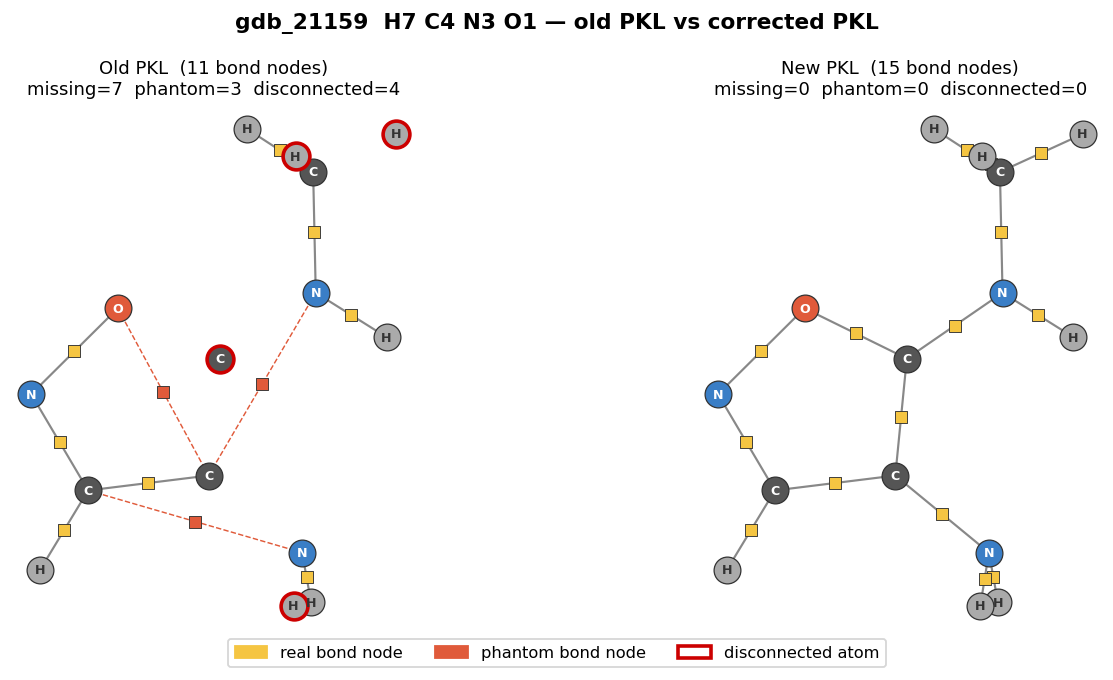

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np, os, json

SAMPLE_GDB = 21159
row    = df[df["gdb_num"] == SAMPLE_GDB].iloc[0]
mol_id = int(row["ids"])
mg     = row["molecule_graph"]
mol    = mg.molecule
n_atoms = len(mol.sites)
species = [get_species(s) for s in mol.sites]
xy      = np.array([s.coords[:2] for s in mol.sites])
xy     -= xy.mean(axis=0)
mg_edges = {(min(u,v),max(u,v)) for u,v,_ in mg.graph.edges(data=True)}

# old bonds
old_raw = row["bonds"]
if isinstance(old_raw,list) and len(old_raw)==1: old_raw=old_raw[0]
old_bonds = sorted({(min(i,j),max(i,j)) for i,j in old_raw if i!=j})

# new bonds
qpath = os.path.join(QTAIM_ROOT, str(mol_id), "qtaim.json")
with open(qpath) as f: q=json.load(f)
new_bonds = sorted({(min(int(k.split("_")[0]),int(k.split("_")[1])),
                      max(int(k.split("_")[0]),int(k.split("_")[1])))
                     for k in q if "_" in str(k)
                     and float(q[k].get("density_all",0))>0.05
                     and int(k.split("_")[0])!=int(k.split("_")[1])} | mg_edges)

ELEM_COLOR = {"C":"#555555","N":"#3A7EC6","O":"#E05A3A","H":"#AAAAAA","F":"#4CAF50"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"gdb_{SAMPLE_GDB}  {mol.composition.formula} — old PKL vs corrected PKL",
             fontsize=12, fontweight="bold")

for ax, bonds, title in [
    (ax1, old_bonds, f"Old PKL  ({len(old_bonds)} bond nodes)"),
    (ax2, new_bonds, f"New PKL  ({len(new_bonds)} bond nodes)")]:

    connected = {i for b in bonds for i in b}
    for i,j in bonds:
        mid = (xy[i]+xy[j])/2
        real = (i,j) in mg_edges
        for a in [i,j]:
            ax.plot([xy[a,0],mid[0]],[xy[a,1],mid[1]],
                    color="#888" if real else "#E05A3A",
                    lw=1.2 if real else 0.8,
                    ls="-" if real else "--", zorder=1)
        ax.scatter(*mid, marker="s", s=50,
                   color="#F5C542" if real else "#E05A3A",
                   edgecolors="#333", lw=0.5, zorder=3)
    for i in range(n_atoms):
        dc = i not in connected
        ax.scatter(xy[i,0],xy[i,1], s=220,
                   color=ELEM_COLOR.get(species[i],"#AAA"),
                   edgecolors="#CC0000" if dc else "#333",
                   linewidths=2 if dc else 0.7, zorder=4)
        ax.text(xy[i,0],xy[i,1], species[i], ha="center", va="center",
                fontsize=7, fontweight="bold", zorder=5,
                color="white" if species[i] in ("C","N","O") else "#333")

    miss = len(mg_edges - set(bonds))
    phan = len(set(bonds) - mg_edges)
    disc = sum(1 for i in range(n_atoms) if i not in connected)
    ax.set_title(f"{title}\nmissing={miss}  phantom={phan}  disconnected={disc}",
                 fontsize=10)
    ax.set_aspect("equal"); ax.axis("off")

handles = [
    mpatches.Patch(color="#F5C542", label="real bond node"),
    mpatches.Patch(color="#E05A3A", label="phantom bond node"),
    mpatches.Patch(facecolor="white", edgecolor="#CC0000", lw=2, label="disconnected atom"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5,-0.04))
plt.tight_layout()
out = "/tmp/graph_comparison_gdb21159.png"
plt.savefig(out, dpi=130, bbox_inches="tight")
plt.close()
from IPython.display import Image, display
display(Image(out))

In [9]:
pwd

'/home/suba/Documents/GitHub/qtaim_embed_private'